<a href="https://colab.research.google.com/github/ahmedhazemelesayed-debug/autoworth-AI/blob/main/AutoWorth_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 AutoWorth AI — Used Car Price & Deal Advisor
**Final Machine Learning Project (individual)** · Author: _write your name here_

**Question the system answers:** *"What is the expected market price of this car, and is the seller offering a good deal?"*

**Pipeline:** Raw data → Cleaning → EDA → Split → Feature engineering → Preprocessing → 5 models → Evaluation → Overfitting check → Tuning → Final model (test set) → Model understanding → Smart Deal Advisor → Streamlit app

**Dataset:** 100,000 UK Used Car Dataset (Kaggle, `adityadesai13`) — 9 manufacturers: Audi, BMW, Ford, Hyundai, Mercedes, Skoda, Toyota, Vauxhall, Volkswagen. **Target:** `price` (regression).

> ▶️ **How to run on Google Colab:** upload the dataset zip when asked in step 1 (or put the CSVs in a `data/` folder next to the notebook), then *Runtime → Run all*. XGBoost is pre-installed on Colab and is used automatically as the 5th model.

### ▶️ Colab setup (run first)
This cell downloads the project (data included) from GitHub and installs XGBoost. If you did not upload the repo, skip it: step 1 will ask you to upload the dataset zip instead.

In [1]:
import os
GITHUB_USER = "ahmedhazemelesayed-debug"   # <- your GitHub username
if not os.path.exists("data/audi.csv"):
    !git clone https://github.com/{GITHUB_USER}/autoworth-AI.git
    %cd autoworth-AI
!pip install -q xgboost

Cloning into 'autoworth-AI'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 32 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 3.29 MiB | 12.33 MiB/s, done.
/content/autoworth-AI


## 0️⃣ Setup
Libraries, a fixed random seed (`RANDOM_STATE = 42`) so every result is reproducible, and a dictionary `RESULTS` that collects all final numbers (saved to `results.json` at the end). Figures are saved to `figures/`.

In [2]:
import os, json, time, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from IPython.display import display
except ImportError:           # plain python run
    display = print

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)
RESULTS = {}                  # everything we report is collected here (-> results.json)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=130, bbox_inches="tight")
    plt.show()


## 1️⃣ Load & understand the data
The brief names nine manufacturer files. The zip also contains `cclass.csv`, `focus.csv` (sub-sets of the Mercedes and Ford files) and two `unclean ...` files (raw scrape dumps in a different, messy format). **They are not used** — using them would add duplicated cars.

A new **`Make`** column is created for every file *before* combining, as the project requires. For each file we check size, columns, types, missing values and duplicates.

**What the inspection shows:** 99,187 rows in total; **no missing values** in any file; **1,475 duplicated rows** (Vauxhall 374, Volkswagen 264, Mercedes 259, ...); the Hyundai file calls its tax column `tax(£)` instead of `tax`; and model names carry a leading space (`" A1"`).

In [3]:
# Locate the CSV files (repo layout: ./data/*.csv). On Colab, upload the zip if they are missing.
def find_data_dir():
    for d in ["data", "/content/data", "/content", "."]:
        if os.path.exists(os.path.join(d, "audi.csv")):
            return d
    try:
        from google.colab import files
        print("Upload the dataset zip (archive.zip) ...")
        up = files.upload()
        os.makedirs("data", exist_ok=True)
        for fn in up:
            if fn.endswith(".zip"):
                zipfile.ZipFile(fn).extractall("data")
        return "data"
    except ImportError:
        raise FileNotFoundError("Put the dataset CSV files in a ./data folder.")

DATA_DIR = find_data_dir()
print("Data folder:", DATA_DIR)

# The 9 manufacturer files named in the project brief.
# (cclass / focus / "unclean ..." files are NOT used: cclass & focus are sub-sets of the Mercedes & Ford
#  files and the "unclean" ones are raw scrape dumps with a different, messy format.)
FILES = {"audi": "Audi", "bmw": "BMW", "ford": "Ford", "hyundi": "Hyundai", "merc": "Mercedes",
         "skoda": "Skoda", "toyota": "Toyota", "vauxhall": "Vauxhall", "vw": "Volkswagen"}

raw = {}
for f, make in FILES.items():
    d = pd.read_csv(os.path.join(DATA_DIR, f + ".csv"))
    d["Make"] = make                         # new Make column BEFORE combining
    raw[make] = d

summary = pd.DataFrame({
    "rows": {m: d.shape[0] for m, d in raw.items()},
    "columns": {m: d.shape[1] for m, d in raw.items()},
    "missing_values": {m: int(d.isna().sum().sum()) for m, d in raw.items()},
    "duplicate_rows": {m: int(d.duplicated().sum()) for m, d in raw.items()},
})
display(summary)
print("Total rows:", summary["rows"].sum())


Data folder: .


,rows,columns,missing_values,duplicate_rows
Audi,10668,10,0,103
BMW,10781,10,0,117
Ford,17965,10,0,154
Hyundai,4860,10,0,86
Mercedes,13119,10,0,259
Skoda,6267,10,0,79
Toyota,6738,10,0,39
Vauxhall,13632,10,0,374
Volkswagen,15157,10,0,264


Total rows: 99187


In [4]:
# Inspect one file in detail (all files share the same structure), then compare the column names of all files
audi = raw["Audi"]
print(audi.dtypes, "\n")
display(audi.head())
display(audi.describe().T)
print("Transmission:", audi["transmission"].unique(), "| Fuel:", audi["fuelType"].unique())

print("\nColumn names per manufacturer:")
for m, d in raw.items():
    print(f"{m:11s}", list(d.columns))


model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
Make             object
dtype: object 



,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi


,count,mean,std,min,25%,50%,75%,max
year,10668.0,2017.100675,2.167494,1997.0,2016.00,2017.0,2019.0,2020.0
price,10668.0,22896.685039,11714.841888,1490.0,15130.75,20200.0,27990.0,145000.0
mileage,10668.0,24827.244001,23505.257205,1.0,5968.75,19000.0,36464.5,323000.0
tax,10668.0,126.011436,67.170294,0.0,125.00,145.0,145.0,580.0
mpg,10668.0,50.770022,12.949782,18.9,40.90,49.6,58.9,188.3
engineSize,10668.0,1.930709,0.602957,0.0,1.50,2.0,2.0,6.3


Transmission: ['Manual' 'Automatic' 'Semi-Auto'] | Fuel: ['Petrol' 'Diesel' 'Hybrid']

Column names per manufacturer:
Audi        ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']
BMW         ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']
Ford        ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']
Hyundai     ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax(£)', 'mpg', 'engineSize', 'Make']
Mercedes    ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']
Skoda       ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']
Toyota      ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']
Vauxhall    ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'ta

## 2️⃣ Combine the data
Fixes needed before concatenating: rename Hyundai's `tax(£)` → `tax` (otherwise pandas would create a second, half-empty tax column) and strip the whitespace from model names. After combining we re-check missing values, duplicates, types and suspicious values.

**Suspicious values found:** 3 impossible years (one `2060`, two `1970`), 273 cars with engine size `0`, 278 cars with mpg above 150 and 35 below 15, 9 cars above 200k miles, 29 cars below £1,000, and tiny categories (`Other` transmission / fuel type).

In [5]:
# Problems found above: Hyundai calls the tax column "tax(£)" and model names have a leading space.
raw["Hyundai"] = raw["Hyundai"].rename(columns={"tax(£)": "tax"})

df = pd.concat(raw.values(), ignore_index=True)
df.columns = [c.strip() for c in df.columns]
df["model"] = df["model"].str.strip()        # " A1" -> "A1"  (inconsistent categories)

print("Combined shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
display(df.describe().T)
RESULTS["rows_raw"] = int(len(df))


Combined shape: (99187, 10)

Data types:
 model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
Make             object
dtype: object

Missing values:
 model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

Duplicate rows: 1475


,count,mean,std,min,25%,50%,75%,max
year,99187.0,2017.087723,2.123934,1970.0,2016.0,2017.0,2019.0,2060.0
price,99187.0,16805.347656,9866.773417,450.0,9999.0,14495.0,20870.0,159999.0
mileage,99187.0,23058.914213,21148.523721,1.0,7425.0,17460.0,32339.0,323000.0
tax,99187.0,120.299838,63.150926,0.0,125.0,145.0,145.0,580.0
mpg,99187.0,55.166825,16.138522,0.3,47.1,54.3,62.8,470.8
engineSize,99187.0,1.663280,0.557646,0.0,1.2,1.6,2.0,6.6


In [6]:
# Suspicious / unrealistic values after combining
print("Years outside 1995-2020 :", ((df.year < 1995) | (df.year > 2020)).sum())
print("engineSize == 0         :", (df.engineSize == 0).sum())
print("mpg > 150 / mpg < 15    :", (df.mpg > 150).sum(), "/", (df.mpg < 15).sum())
print("mileage > 200,000       :", (df.mileage > 200_000).sum())
print("price < 1,000           :", (df.price < 1000).sum())
print("tax == 0                :", (df.tax == 0).sum())
for col in ["transmission", "fuelType"]:
    print(f"\n{col}:\n", df[col].value_counts().to_string())


Years outside 1995-2020 : 3
engineSize == 0         : 273
mpg > 150 / mpg < 15    : 278 / 35
mileage > 200,000       : 9
price < 1,000           : 29
tax == 0                : 6294

transmission:
 transmission
Manual       56445
Semi-Auto    22677
Automatic    20056
Other            9

fuelType:
 fuelType
Petrol      54928
Diesel      40928
Hybrid       3078
Other         247
Electric        6


## 3️⃣ Data cleaning — every decision explained
| Problem | What I found when investigating | Decision | Why |
|---|---|---|---|
| **Duplicate rows** | 1,475 identical rows (no listing ID exists) | Removed | Same advert scraped twice; duplicates would also appear in both train *and* test and inflate the score |
| **Invalid years** | `2060` Ford Fiesta (scraped in 2020 → impossible, real year unknowable); two `1970` rows (Mercedes M Class, Vauxhall Zafira — models that did not exist in 1970; default-date bug) | Dropped these **3 rows only** | They cannot be repaired reliably |
| **Engine size = 0** | 265 petrol / diesel / hybrid cars with a 0.0 L engine; only electric cars can legitimately have no engine | `0 → NaN` for non-electric cars, imputed **later with the training median** + flag feature `engine_missing` | Deleting 265 rows would waste data; imputing before the split would leak test information |
| **MPG outliers** | mpg > 150 are almost all plug-in hybrids / EVs (real lab figures, up to 470); mpg < 15 are plug-in-hybrid BMWs or entry errors (0.3, 1.1) | Kept the rows, **clipped mpg to [10, 150]** | Listings are real; clipping stops extreme values wrecking scaling & linear models; `fuelType` still identifies hybrids |
| **Price outliers** | Cheapest £450 = 15–20 year-old cars with 90–180k miles; most expensive £140–160k = G-Class / AMG / Audi R8 | **Kept** | Realistic market extremes, not errors |
| **Mileage outliers** | 9 cars above 200k miles (max 323k) are 8–12 years old and cheap | **Kept** | Realistic; tree models are robust to them |
| **Inconsistent categories** | Leading spaces in model names; no case-variants; `Other` (9 transmission, 246 fuel) | Stripped spaces; `Other` kept as its own class | Honest "unknown" category, too small to matter |

**Result:** 97,709 clean rows (98.5% of the raw data); the only remaining missing values are the 265 engine sizes that are imputed after the split.

In [7]:
# --- 3.1 Duplicates -----------------------------------------------------------------------------
# There is no listing ID, so fully identical rows are almost certainly the same advert scraped twice.
# Keeping them would also put identical cars in train AND test (leakage) -> remove.
n_dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {n_dup} duplicate rows -> {len(df)} left")

# --- 3.2 Invalid years --------------------------------------------------------------------------
bad_year = df[(df.year < 1995) | (df.year > 2020)]
display(bad_year)


Removed 1475 duplicate rows -> 97712 left


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
38801,Fiesta,2060,6495,Automatic,54807,Petrol,205,42.8,1.4,Ford
55629,M Class,1970,24999,Automatic,14000,Diesel,305,39.2,0.0,Mercedes
80056,Zafira,1970,10495,Manual,37357,Petrol,200,42.2,1.4,Vauxhall


In [8]:
# Investigation: the data was scraped in 2020 so year 2060 is impossible (a typo - the real year cannot be
# recovered with certainty). The two "1970" rows are a classic default-date bug (a Mercedes M Class and a
# Vauxhall Zafira did not exist in 1970). They cannot be repaired reliably -> only these 3 rows are dropped.
df = df[(df.year >= 1995) & (df.year <= 2020)].reset_index(drop=True)
print("Rows after fixing invalid years:", len(df))


Rows after fixing invalid years: 97709


In [9]:
# --- 3.3 Engine size = 0 -------------------------------------------------------------------------
zero_eng = df[df.engineSize == 0]
print(zero_eng.fuelType.value_counts())
print("\nExamples:")
display(zero_eng.sample(5, random_state=1))


fuelType
Petrol      158
Diesel       68
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

Examples:


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
7530,Q3,2020,32444,Automatic,1500,Petrol,145,31.4,0.0,Audi
7654,Q3,2020,29990,Automatic,1500,Diesel,145,47.1,0.0,Audi
37406,Fiesta,2017,11783,Automatic,23000,Petrol,0,57.7,0.0,Ford
17540,i3,2017,22495,Automatic,21025,Hybrid,0,470.8,0.0,BMW
9794,A3,2005,2495,Manual,122000,Diesel,150,53.3,0.0,Audi


In [10]:
# Investigation: a petrol/diesel/hybrid car cannot have a 0.0 litre engine -> this is a "missing" code.
# Only electric cars legitimately have no combustion engine, so 0 is kept for Electric.
# For all other cars we convert 0 -> NaN and impute it later using the TRAINING set only (no leakage);
# a flag feature (engine_missing) lets the model know the value was imputed.
mask = (df.engineSize == 0) & (df.fuelType != "Electric")
df.loc[mask, "engineSize"] = np.nan
print("Engine sizes converted to NaN:", mask.sum())

# --- 3.4 MPG outliers ----------------------------------------------------------------------------
print("\nmpg > 150 :")
print(df[df.mpg > 150].groupby("fuelType").size())
print("mpg < 15 :")
print(df[df.mpg < 15].groupby(["Make", "model", "fuelType"]).size())


Engine sizes converted to NaN: 265

mpg > 150 :
fuelType
Diesel        2
Electric      4
Hybrid      246
Other        20
Petrol        1
dtype: int64
mpg < 15 :
Make        model     fuelType
BMW         3 Series  Hybrid       8
            X3        Hybrid       6
Hyundai     Ioniq     Hybrid       4
Mercedes    A Class   Hybrid       3
            G Class   Diesel       1
Toyota      C-HR      Petrol       1
            Hilux     Diesel      10
Volkswagen  Golf SV   Petrol       1
dtype: int64


In [11]:
# Investigation: mpg > 150 are almost all plug-in hybrids / EVs (lab figures like 470 mpg are real but not
# comparable to petrol cars) and mpg < 15 are plug-in hybrid BMWs or entry errors (0.3 / 1.1 mpg).
# They are REAL listings, so rows are kept, but extreme values are clipped (winsorised) to [10, 150]
# so they do not distort scaling / linear models. The fuelType feature still tells hybrids apart.
df["mpg"] = df["mpg"].clip(10, 150)

# --- 3.5 Price & mileage ---------------------------------------------------------------------------
print("Cheapest cars:")
display(df.nsmallest(5, "price")[["Make", "model", "year", "mileage", "price"]])
print("Most expensive cars:")
display(df.nlargest(5, "price")[["Make", "model", "year", "mileage", "price", "engineSize"]])
print("Highest mileage:")
display(df.nlargest(5, "mileage")[["Make", "model", "year", "mileage", "price"]])


Cheapest cars:


,Make,model,year,mileage,price
75175,Vauxhall,Astra,2001,159000,450
82803,Vauxhall,Agila,2003,90000,450
38179,Ford,Focus,2003,177644,495
72661,Vauxhall,Corsa,2002,99842,495
72675,Vauxhall,Corsa,2003,82000,590


Most expensive cars:


,Make,model,year,mileage,price,engineSize
49916,Mercedes,G Class,2020,1350,159999,4.0
53612,Mercedes,G Class,2020,3000,154998,4.0
43818,Mercedes,SL CLASS,2011,3000,149948,6.2
4743,Audi,R8,2020,2000,145000,5.2
52356,Mercedes,A Class,2019,785,140319,4.0


Highest mileage:


,Make,model,year,mileage,price
9719,Audi,A6,2008,323000,2490
62662,Skoda,Octavia,2010,300000,1190
80036,Vauxhall,Zafira,2013,279000,1395
54901,Mercedes,V Class,2010,259000,6949
62179,Skoda,Octavia,2010,250650,1485


In [12]:
# Investigation: cheapest cars (~£450) are 15-20 year old cars with 90k-180k miles -> realistic.
# Most expensive cars (£140k-£160k) are Mercedes G-Class / AMG and Audi R8 -> realistic supercars/SUVs.
# Mileage 200k-323k: 9 old high-mileage cars with correspondingly low prices -> realistic.
# => No price or mileage values are removed. Tree models are robust to them and they are genuine market cases.

# Sanity check: very old cars with almost no miles (could be data entry errors)
odd = df[(df.year <= 2010) & (df.mileage < 5000)]
print("Cars <= 2010 with < 5,000 miles:", len(odd))

# --- 3.6 Inconsistent categories ------------------------------------------------------------------
print("\nModels with different spelling only (case):", df.model.nunique() - df.model.str.lower().nunique())
print("'Other' categories kept as their own class -> transmission:", (df.transmission == "Other").sum(),
      "| fuelType:", (df.fuelType == "Other").sum())

RESULTS["rows_clean"] = int(len(df))
RESULTS["duplicates_removed"] = int(n_dup)
print("\nFinal cleaned dataset:", df.shape, "| missing values:\n", df.isna().sum()[lambda s: s > 0])


Cars <= 2010 with < 5,000 miles: 4

Models with different spelling only (case): 0
'Other' categories kept as their own class -> transmission: 9 | fuelType: 246

Final cleaned dataset: (97709, 10) | missing values:
 engineSize    265
dtype: int64


## 4️⃣ Exploratory data analysis
Seven visualisations, each with a conclusion.

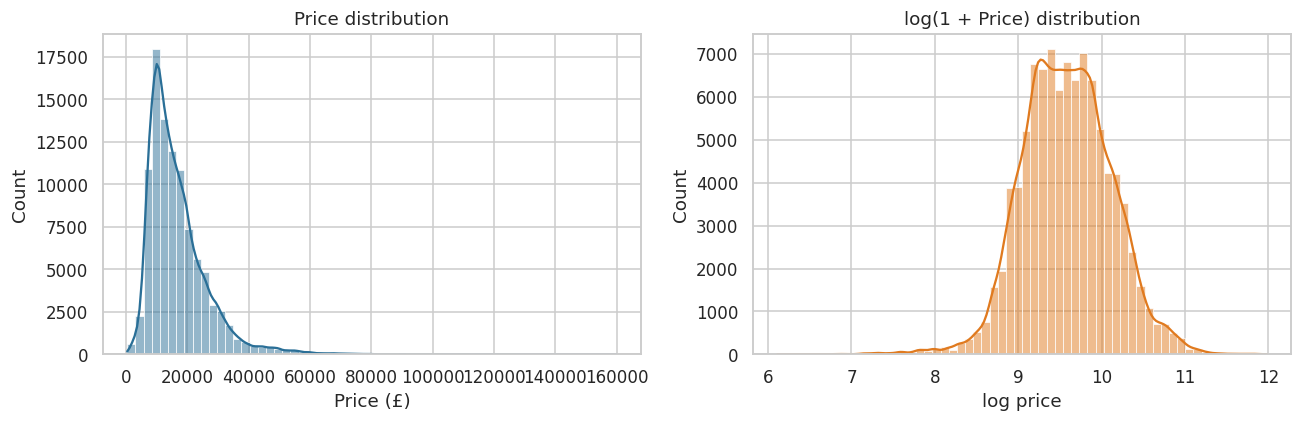

Mean £16,774 | Median £14,470 | Skewness 2.36 -> log skew -0.08


In [13]:
# 1) Price distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.price, bins=60, kde=True, ax=ax[0], color="#2a6f97")
ax[0].set_title("Price distribution"); ax[0].set_xlabel("Price (£)")
sns.histplot(np.log1p(df.price), bins=60, kde=True, ax=ax[1], color="#e07a1f")
ax[1].set_title("log(1 + Price) distribution"); ax[1].set_xlabel("log price")
savefig("01_price_distribution")
print(f"Mean £{df.price.mean():,.0f} | Median £{df.price.median():,.0f} | Skewness {df.price.skew():.2f} -> log skew {np.log1p(df.price).skew():.2f}")


**📌 Conclusion — price distribution.** Prices are strongly right-skewed (mean £16,774 vs median £14,470, skewness 2.36): most cars are cheap/mid-priced with a long tail of luxury cars. After a log transform the distribution is almost symmetric (skewness −0.08). → **All models are trained on `log(1+price)`** and their predictions are converted back to pounds; this treats a £1,000 error on a £5,000 car as more serious than on a £50,000 car, which is exactly what a buyer cares about.

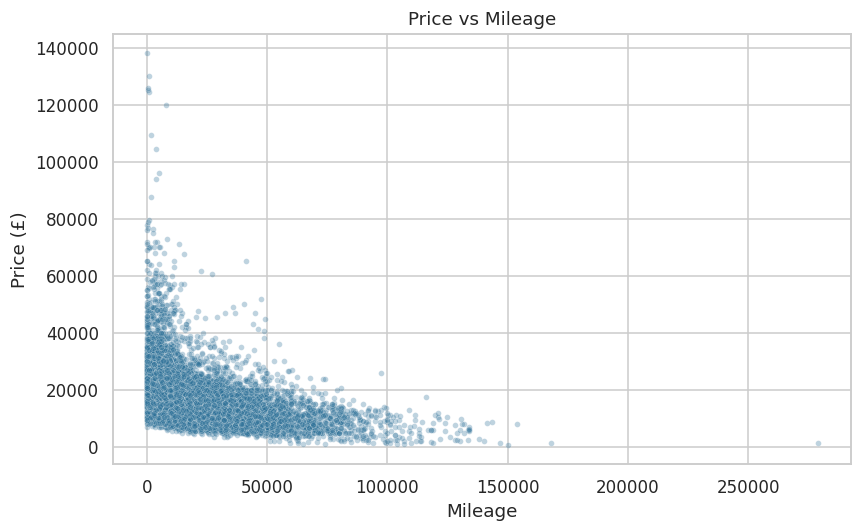

Correlation (price, mileage): -0.418


In [14]:
# 2) Price vs Mileage
sample = df.sample(10000, random_state=1)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="mileage", y="price", alpha=0.3, s=14, color="#2a6f97")
plt.title("Price vs Mileage"); plt.xlabel("Mileage"); plt.ylabel("Price (£)")
savefig("02_price_vs_mileage")
print("Correlation (price, mileage):", round(df[["price", "mileage"]].corr().iloc[0, 1], 3))


**📌 Conclusion — price vs mileage.** Clear negative relationship (correlation −0.42): price falls quickly during the first ~40,000 miles and then flattens. The cloud is wide because mileage is mixed up with age, make and model — a high-mileage Mercedes can still cost more than a low-mileage Vauxhall — so mileage alone is only a rough predictor.

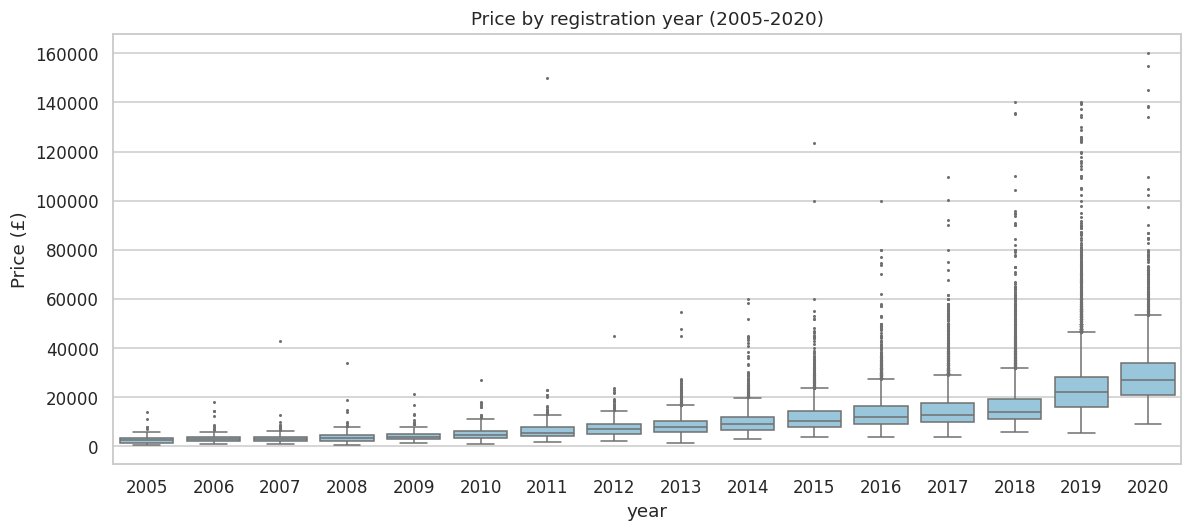

year
2005     2495.0
2010     4497.0
2015    10490.0
2018    14158.0
2020    26990.0


In [15]:
# 3) Price vs Year
plt.figure(figsize=(11, 5))
order = sorted(df.year[df.year >= 2005].unique())
sns.boxplot(data=df[df.year >= 2005], x="year", y="price", order=order, color="#8ecae6", fliersize=1)
plt.title("Price by registration year (2005-2020)"); plt.ylabel("Price (£)")
savefig("03_price_vs_year")
print(df.groupby("year").price.median().loc[[2005, 2010, 2015, 2018, 2020]].round(0).to_string())


**📌 Conclusion — price vs year.** Newer cars are much more expensive: median price is £2,495 for 2005 cars, £4,497 for 2010, £10,490 for 2015, £14,158 for 2018 and £26,990 for 2020 (near-new). The spread also widens with newer years, because new luxury models are far more expensive than new small cars. Age is clearly one of the strongest drivers of price.

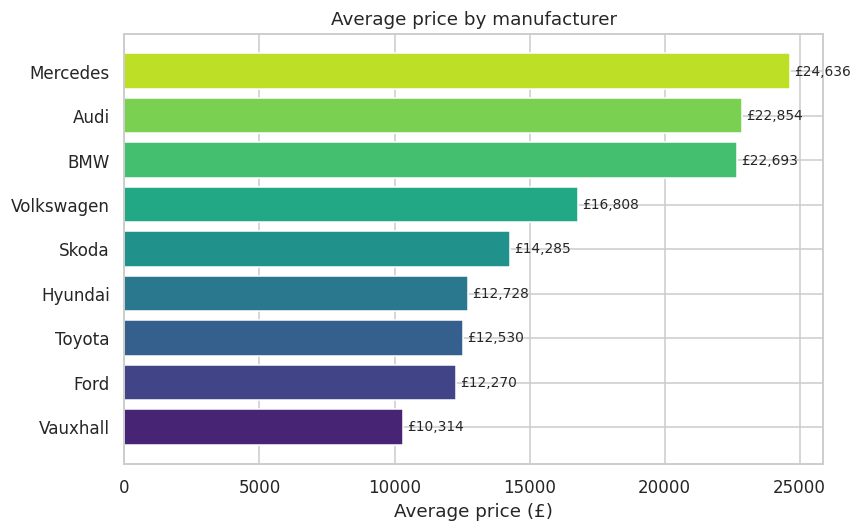

,mean,median,count
Make,,,
Vauxhall,10314.0,9998.0,13257
Ford,12270.0,11290.0,17810
Toyota,12530.0,10798.0,6699
Hyundai,12728.0,11992.0,4774
Skoda,14285.0,12998.0,6188
Volkswagen,16808.0,15494.0,14893
BMW,22693.0,20262.0,10664
Audi,22854.0,20000.0,10565
Mercedes,24636.0,22299.0,12859


In [16]:
# 4) Average price by manufacturer
avg = df.groupby("Make").price.agg(["mean", "median", "count"]).sort_values("mean")
plt.figure(figsize=(8, 5))
plt.barh(avg.index, avg["mean"], color=sns.color_palette("viridis", len(avg)))
for i, v in enumerate(avg["mean"]):
    plt.text(v + 150, i, f"£{v:,.0f}", va="center", fontsize=9)
plt.title("Average price by manufacturer"); plt.xlabel("Average price (£)")
savefig("04_avg_price_by_make")
display(avg.round(0))


**📌 Conclusion — manufacturers.** Two clear groups: **premium** (Mercedes £24.6k, Audi £22.9k, BMW £22.7k) and **mainstream** (Volkswagen £16.8k, Skoda £14.3k, Hyundai £12.7k, Toyota £12.5k, Ford £12.3k, Vauxhall £10.3k). Mercedes is on average 2.4× as expensive as Vauxhall. This motivated the `is_premium_brand` feature.

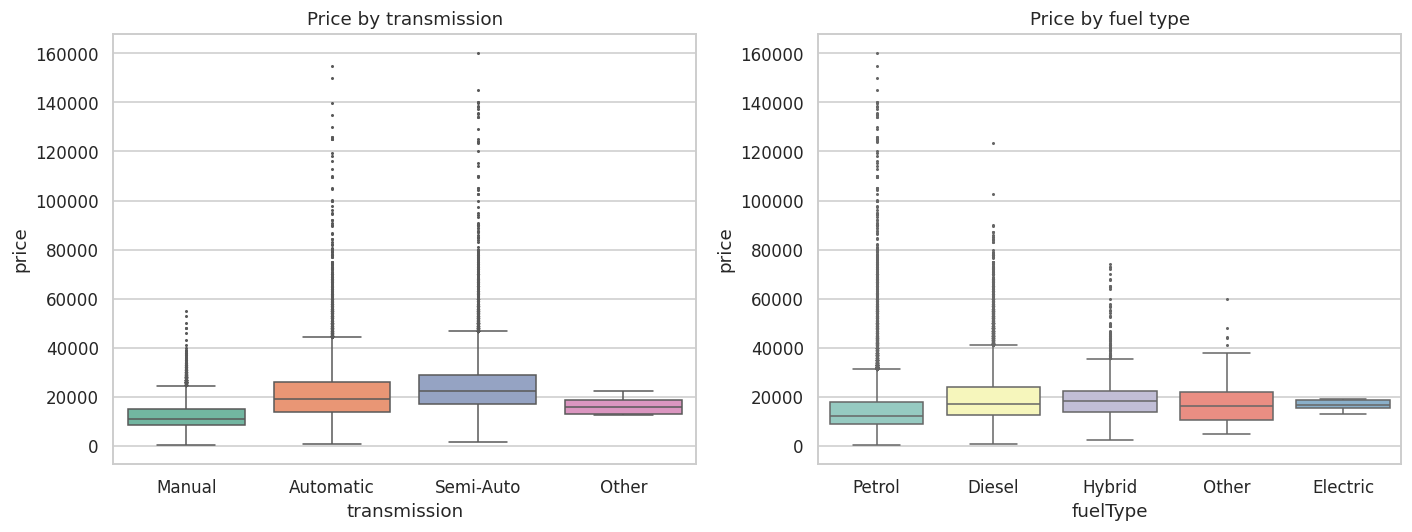

transmission
Automatic    19245.0
Manual       11000.0
Other        15999.0
Semi-Auto    22250.0
fuelType
Diesel      17000.0
Electric    16688.0
Hybrid      18200.0
Other       16450.0
Petrol      11998.0


In [17]:
# 5) Price by transmission & 6) Price by fuel type
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="transmission", y="price", ax=ax[0], palette="Set2", fliersize=1)
ax[0].set_title("Price by transmission")
sns.boxplot(data=df, x="fuelType", y="price", ax=ax[1], palette="Set3", fliersize=1)
ax[1].set_title("Price by fuel type")
savefig("05_price_by_transmission_fuel")
print(df.groupby("transmission").price.median().round(0).to_string())
print(df.groupby("fuelType").price.median().round(0).to_string())


**📌 Conclusion — transmission and fuel type.** Manual cars have a median price of £11,000 versus £19,245 for Automatic and £22,250 for Semi-Auto. Petrol cars are cheapest (£11,998) while Diesel (£17,000) and Hybrid (£18,200) cost more. Part of this is a *mix effect* (diesels and automatics are more common in bigger / premium models), so the model must consider these features together with the model name rather than alone.

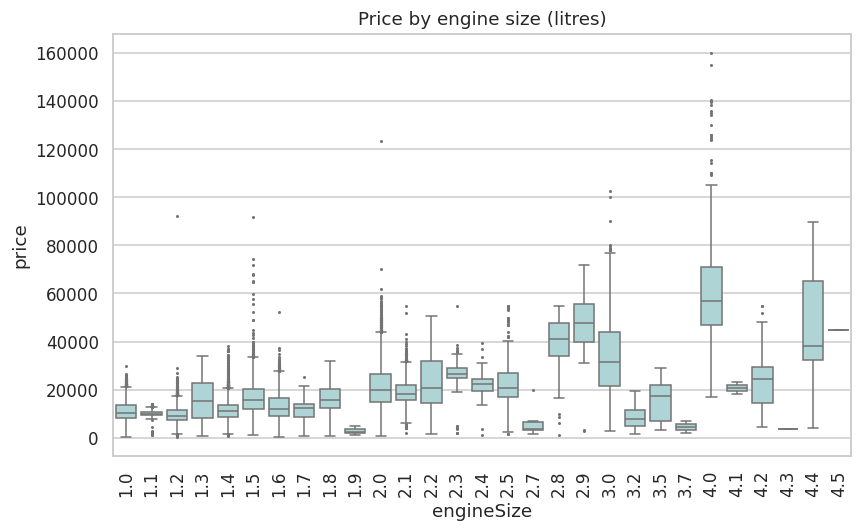

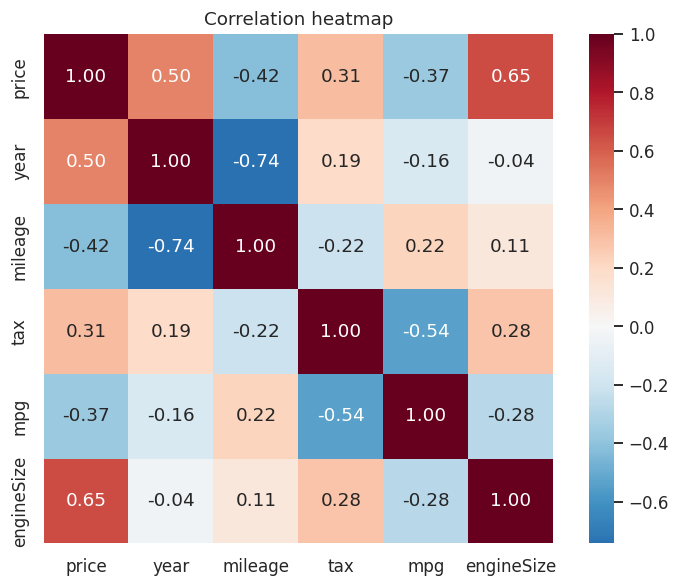

price         1.00
year          0.50
mileage      -0.42
tax           0.31
mpg          -0.37
engineSize    0.65


In [18]:
# 7) Price vs Engine size
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df.engineSize.between(0.9, 4.5)], x="engineSize", y="price", color="#a8dadc", fliersize=1)
plt.xticks(rotation=90); plt.title("Price by engine size (litres)")
savefig("06_price_vs_engine")

# 8) Correlation heatmap (numeric columns)
num_cols = ["price", "year", "mileage", "tax", "mpg", "engineSize"]
plt.figure(figsize=(7, 5.5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation heatmap")
savefig("07_correlation_heatmap")
print(df[num_cols].corr()["price"].round(2).to_string())


**📌 Conclusion — engine size & correlations.** Engine size has the **strongest correlation with price (0.65)**, followed by year (0.50), mileage (−0.42), mpg (−0.37) and tax (0.31). Bigger engines cost more, and fuel-efficient cars (high mpg) are cheaper because they are small economy cars. The correlations are moderate rather than extreme, which tells us no single numeric column explains price — the combination with make/model matters (that is where tree-based models shine).

## 6️⃣ Feature engineering (placed *before* the split on purpose)
Every feature below is a **row-by-row formula** — nothing is learned from the data — so creating them before the split cannot leak information. (Anything that *is* fitted — imputer, scaler, encoder — is fitted on the training set only, see step 7.)

| Feature | Formula | Why it should help |
|---|---|---|
| `car_age` | `2020 − year` (reference year **2020** = the year the data was scraped, the newest car in the data is 2020) | Age is the main driver of depreciation; easier for linear models than the raw year |
| `mileage_per_year` | `mileage / max(car_age, 1)` (age is clipped to ≥ 1 so brand-new cars never divide by zero) | Separates *heavily used* from *lightly used* cars of the same age (a 5-year-old car with 10k miles vs 100k miles) |
| `is_premium_brand` | 1 if Make ∈ {Audi, BMW, Mercedes} | EDA shows premium makes cost about double; gives linear models a simple brand signal |
| `engine_mpg_ratio` | `engineSize / mpg` | Proxy for performance vs economy (big thirsty engines = sporty / luxury models) |
| `engine_missing` | 1 if engine size was missing/invalid in the raw data | Lets the model know that the value was imputed |

I dropped the raw `year` column from the model inputs because `car_age` carries exactly the same information (duplicated information only hurts linear models).

In [19]:
REFERENCE_YEAR = 2020          # the dataset was scraped in 2020 -> newest car is 2020
PREMIUM_MAKES = ["Audi", "BMW", "Mercedes"]

def add_features(df):
    """Row-wise feature engineering (nothing is learned from data -> no leakage)."""
    df = df.copy()
    # 1) Car age (years) - never negative
    df["car_age"] = (REFERENCE_YEAR - df["year"]).clip(lower=0)
    # 2) Mileage per year - car_age is clipped to >= 1 so brand-new cars never divide by zero
    df["mileage_per_year"] = df["mileage"] / df["car_age"].clip(lower=1)
    # 3) Premium brand flag
    df["is_premium_brand"] = df["Make"].isin(PREMIUM_MAKES).astype(int)
    # 4) Engine size relative to fuel economy (power-vs-economy proxy)
    df["engine_mpg_ratio"] = df["engineSize"] / df["mpg"]
    # 5) Flag: engine size was missing/invalid in the raw data (imputed later, on train only)
    df["engine_missing"] = df["engineSize"].isna().astype(int)
    return df


In [20]:
df = add_features(df)
display(df[["Make", "model", "year", "mileage", "car_age", "mileage_per_year", "is_premium_brand",
            "engineSize", "mpg", "engine_mpg_ratio", "engine_missing"]].head())
print("Zero-age cars handled safely, max mileage_per_year:", round(df.mileage_per_year.max()),
      "| any inf:", np.isinf(df.mileage_per_year).any())
print(df[["price", "car_age", "mileage_per_year", "is_premium_brand", "engine_mpg_ratio"]].corr()["price"].round(2).to_string())


,Make,model,year,mileage,car_age,mileage_per_year,is_premium_brand,engineSize,mpg,engine_mpg_ratio,engine_missing
0,Audi,A1,2017,15735,3,5245.000000,1,1.4,55.4,0.025271,0
1,Audi,A6,2016,36203,4,9050.750000,1,2.0,64.2,0.031153,0
2,Audi,A1,2016,29946,4,7486.500000,1,1.4,55.4,0.025271,0
3,Audi,A4,2017,25952,3,8650.666667,1,2.0,67.3,0.029718,0
4,Audi,A3,2019,1998,1,1998.000000,1,1.0,49.6,0.020161,0


Zero-age cars handled safely, max mileage_per_year: 132644 | any inf: False
price               1.00
car_age            -0.50
mileage_per_year   -0.19
is_premium_brand    0.50
engine_mpg_ratio    0.69


## 5️⃣ Split the data — 70% train / 15% validation / 15% test
Two calls to `train_test_split` (70 / 30, then the 30% is halved). The **test set stays untouched** until the final model has been chosen. Preprocessing is fitted only on the training part (next step).

In [21]:
TARGET = "price"
NUM_FEATURES = ["mileage", "tax", "mpg", "engineSize", "car_age", "mileage_per_year",
                "engine_mpg_ratio", "is_premium_brand", "engine_missing"]
CAT_FEATURES = ["Make", "model", "transmission", "fuelType"]
FEATURES = NUM_FEATURES + CAT_FEATURES

X = df[FEATURES]
y = df[TARGET]

# 70% train / 15% validation / 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)

for name, part in [("Train", X_train), ("Validation", X_val), ("Test", X_test)]:
    print(f"{name:10s}: {len(part):6d} rows ({len(part) / len(X):.0%})")
RESULTS["split"] = {"train": len(X_train), "val": len(X_val), "test": len(X_test)}


Train     :  68396 rows (70%)
Validation:  14656 rows (15%)
Test      :  14657 rows (15%)


## 7️⃣ Preprocessing (fit on the training set only)
* **Numerical** (`mileage, tax, mpg, engineSize, car_age, mileage_per_year, engine_mpg_ratio, is_premium_brand, engine_missing`): median imputation (this is where the 265 invalid engine sizes get a value — the median of the **training** set) + standard scaling.
* **Categorical** (`Make, model, transmission, fuelType`): One-Hot Encoding with `handle_unknown="ignore"`, so an unseen category at prediction time cannot crash the app.

`fit_transform` is called on the training data only; validation and test only get `transform` → **no data leakage**.

In [22]:
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])
categorical_pipe = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer([("num", numeric_pipe, NUM_FEATURES),
                                  ("cat", categorical_pipe, CAT_FEATURES)])

# FIT on the training data ONLY, then only TRANSFORM validation and test
X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print("Numerical features :", NUM_FEATURES)
print("Categorical features:", CAT_FEATURES)
print(f"Shapes -> train {X_train_p.shape} | val {X_val_p.shape} | test {X_test_p.shape}")
print("Training imputer median for engineSize:", preprocessor.named_transformers_["num"]["imputer"].statistics_[3])


Numerical features : ['mileage', 'tax', 'mpg', 'engineSize', 'car_age', 'mileage_per_year', 'engine_mpg_ratio', 'is_premium_brand', 'engine_missing']
Categorical features: ['Make', 'model', 'transmission', 'fuelType']
Shapes -> train (68396, 218) | val (14656, 218) | test (14657, 218)
Training imputer median for engineSize: 1.6


## 8️⃣ Train five regression models
Linear Regression, Decision Tree, Random Forest, Gradient Boosting and **XGBoost** (on Colab it is installed by the setup cell; if the library is missing the code automatically falls back to scikit-learn's `HistGradientBoostingRegressor`, the same family of algorithm). All models learn `log(1+price)` via `TransformedTargetRegressor`, and every metric is computed on the real £ price.

In [23]:
# Price is right-skewed (see EDA), so every model learns log(1+price) and its predictions are converted
# back to pounds (TransformedTargetRegressor). All metrics below are in real £.
def with_log_target(reg):
    return TransformedTargetRegressor(regressor=reg, func=np.log1p, inverse_func=np.expm1)

try:
    from xgboost import XGBRegressor
    BOOST_NAME = "XGBoost"
    boost_reg = XGBRegressor(n_estimators=500, learning_rate=0.08, max_depth=8, subsample=0.8,
                             colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
    BOOST_PARAMS = {"model__regressor__n_estimators": [300, 500, 800],
                    "model__regressor__learning_rate": [0.03, 0.05, 0.08, 0.12],
                    "model__regressor__max_depth": [6, 8, 10],
                    "model__regressor__subsample": [0.7, 0.8, 1.0],
                    "model__regressor__colsample_bytree": [0.6, 0.8, 1.0],
                    "model__regressor__min_child_weight": [1, 3, 5]}
except ImportError:
    # Fallback when xgboost is not installed (histogram-based gradient boosting = same algorithm family)
    BOOST_NAME = "HistGradientBoosting (XGBoost stand-in)"
    boost_reg = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.1, max_leaf_nodes=63,
                                              random_state=RANDOM_STATE)
    BOOST_PARAMS = {"model__regressor__max_iter": [300, 500],
                    "model__regressor__learning_rate": [0.05, 0.1, 0.15],
                    "model__regressor__max_leaf_nodes": [31, 63, 127],
                    "model__regressor__min_samples_leaf": [10, 20, 40],
                    "model__regressor__l2_regularization": [0.0, 1.0, 5.0]}
print("5th model:", BOOST_NAME)

models = {
    "Linear Regression": with_log_target(LinearRegression()),
    "Decision Tree": with_log_target(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    "Random Forest": with_log_target(RandomForestRegressor(n_estimators=100, max_features=0.33, min_samples_leaf=2,
                                                           n_jobs=-1, random_state=RANDOM_STATE)),
    "Gradient Boosting": with_log_target(GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                                                                   subsample=0.8, max_features=0.5,
                                                                   random_state=RANDOM_STATE)),
    BOOST_NAME: with_log_target(boost_reg),
}

fit_times = {}
for name, m in models.items():
    t0 = time.time()
    m.fit(X_train_p, y_train)
    fit_times[name] = round(time.time() - t0, 1)
    print(f"{name:42s} trained in {fit_times[name]:6.1f}s")


5th model: XGBoost
Linear Regression                          trained in    5.0s
Decision Tree                              trained in    5.4s
Random Forest                              trained in   34.1s
Gradient Boosting                          trained in   94.3s
XGBoost                                    trained in   21.1s


## 9️⃣ Evaluate & compare the models (validation set)

,R² (val),"MAE (£, val)","RMSE (£, val)"
Linear Regression,0.924,1599.378,2739.692
Decision Tree,0.930,1468.127,2622.329
Random Forest,0.957,1139.231,2044.547
Gradient Boosting,0.937,1489.886,2493.056
XGBoost,0.961,1122.375,1964.426


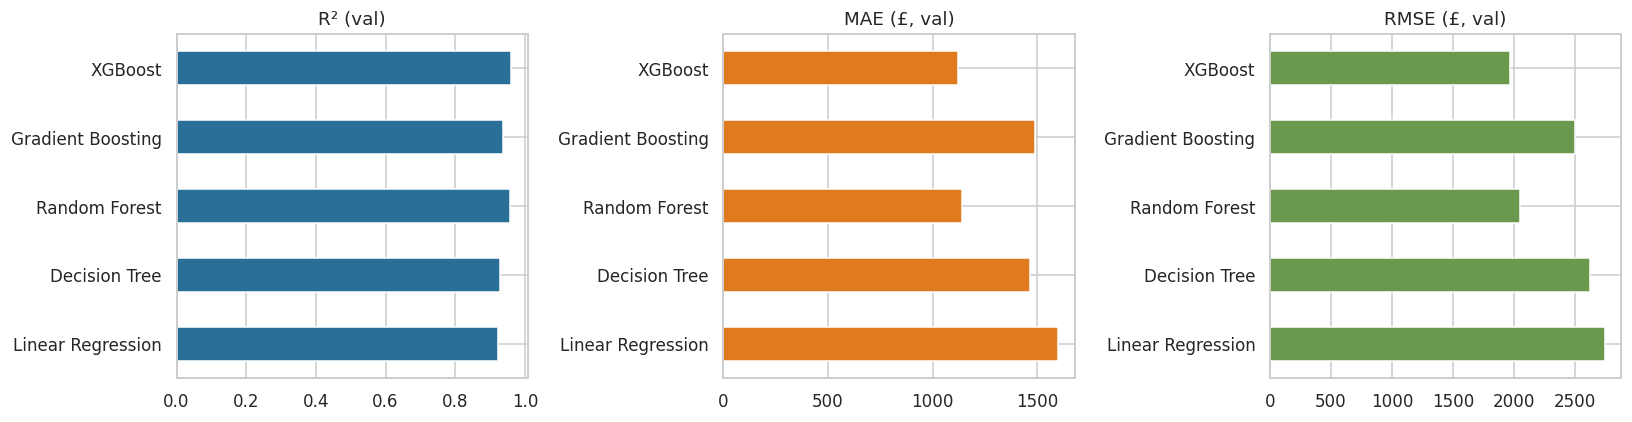

In [24]:
def evaluate(model, Xp, y_true):
    pred = model.predict(Xp)
    return {"R2": r2_score(y_true, pred), "MAE": mean_absolute_error(y_true, pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, pred))}

val_scores = {n: evaluate(m, X_val_p, y_val) for n, m in models.items()}
comparison = pd.DataFrame(val_scores).T.rename(columns={"R2": "R² (val)", "MAE": "MAE (£, val)", "RMSE": "RMSE (£, val)"})
display(comparison.round(3))
RESULTS["validation_comparison"] = {n: {k: float(v) for k, v in s.items()} for n, s in val_scores.items()}

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col, c in zip(ax, comparison.columns, ["#2a6f97", "#e07a1f", "#6a994e"]):
    comparison[col].plot.barh(ax=a, color=c); a.set_title(col)
savefig("08_model_comparison")


**📌 Discussion.** The two boosting/forest models are clearly the best: XGBoost (R² 0.961, MAE £1,122) and Random Forest (R² 0.957, MAE £1,139). Surprisingly, **Linear Regression is already strong (R² 0.924)** — thanks to the log-target and one-hot encoding — but its MAE (£1,599) is much worse because price is not linear in age/mileage. The Decision Tree gets R² 0.930 and sklearn's Gradient Boosting 0.937 (only 200 shallow, sub-sampled trees → it is still under-fitted). All models pass the brief's target of R² > 0.90.

## 🔟 Check for overfitting (train vs validation)

,Train R²,Validation R²,Train MAE (£),Validation MAE (£),R² gap
Linear Regression,0.9194,0.9236,1603.8519,1599.3782,-0.0041
Decision Tree,0.9996,0.9300,19.1120,1468.1274,0.0696
Random Forest,0.9815,0.9574,723.0427,1139.2313,0.0240
Gradient Boosting,0.9428,0.9367,1453.2702,1489.8861,0.0061
XGBoost,0.9757,0.9607,963.1087,1122.3755,0.0151


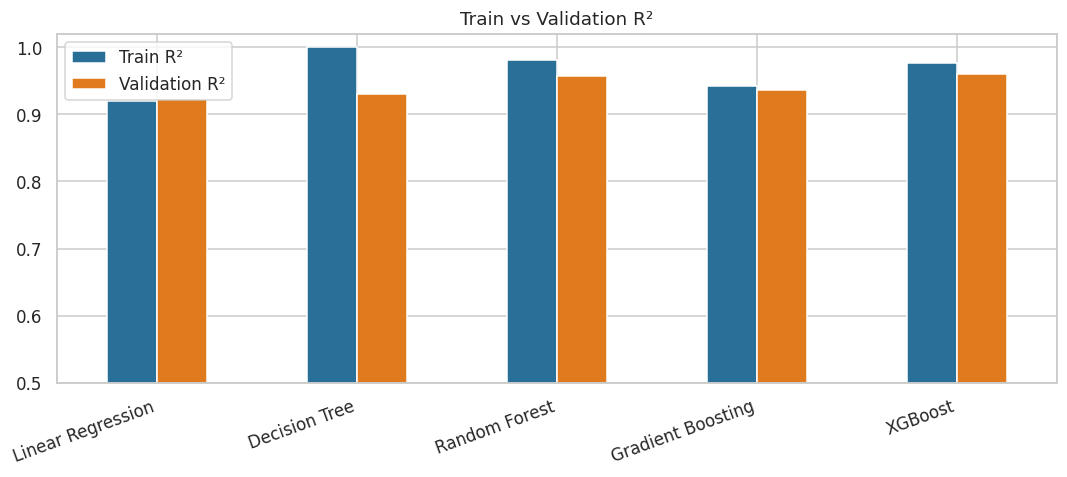

In [25]:
train_scores = {n: evaluate(m, X_train_p, y_train) for n, m in models.items()}
overfit = pd.DataFrame({
    "Train R²": {n: s["R2"] for n, s in train_scores.items()},
    "Validation R²": {n: val_scores[n]["R2"] for n in models},
    "Train MAE (£)": {n: s["MAE"] for n, s in train_scores.items()},
    "Validation MAE (£)": {n: val_scores[n]["MAE"] for n in models},
})
overfit["R² gap"] = overfit["Train R²"] - overfit["Validation R²"]
display(overfit.round(4))
RESULTS["overfitting"] = {n: {k: float(v) for k, v in row.items()} for n, row in overfit.iterrows()}

overfit[["Train R²", "Validation R²"]].plot.bar(figsize=(10, 4.5), color=["#2a6f97", "#e07a1f"])
plt.ylim(0.5, 1.02); plt.xticks(rotation=20, ha="right"); plt.title("Train vs Validation R²")
savefig("09_overfitting_check")


**📌 Discussion.** The **Decision Tree is the clear overfitter**: train R² 0.9996 vs validation 0.930 (gap 0.070) — it memorised the training cars. Random Forest has a moderate gap (0.024, typical for forests: every tree sees the training data). XGBoost (gap 0.015) and Gradient Boosting (0.006) generalise very well, and Linear Regression has no gap at all (it is too simple to overfit, but also limited).

## 1️⃣1️⃣ Improve the best model — hyperparameter tuning
The boosting model has the best validation score and is fast enough to tune, so it is tuned with **RandomizedSearchCV** (8 random combinations × 3-fold CV = 24 fits, scored with R²). The preprocessing sits *inside* the pipeline, so it is re-fitted on each training fold — the cross-validation has no leakage either.

In [26]:
# Tune the boosting model with RandomizedSearchCV (3-fold CV on the TRAINING set only).
# The preprocessing is inside the pipeline, so it is re-fitted inside every CV fold -> no leakage in CV either.
tune_pipe = Pipeline([("prep", clone(preprocessor)), ("model", with_log_target(clone(boost_reg)))])
search = RandomizedSearchCV(tune_pipe, BOOST_PARAMS, n_iter=8, cv=3, scoring="r2",
                            random_state=RANDOM_STATE, n_jobs=1, verbose=1, refit=True)
t0 = time.time()
search.fit(X_train, y_train)
print(f"Search finished in {time.time() - t0:.0f}s")
print("Best params:", {k.replace("model__regressor__", ""): v for k, v in search.best_params_.items()})
print("Best CV R²:", round(search.best_score_, 4))

tuned_model = search.best_estimator_.named_steps["model"]     # fitted on the full training set (same preprocessing)
tuned_name = f"{BOOST_NAME} (tuned)"
before = val_scores[BOOST_NAME]
after = evaluate(tuned_model, X_val_p, y_val)
tuning_table = pd.DataFrame({"Before tuning": before, "After tuning": after}).T
display(tuning_table.round(4))
RESULTS["tuning"] = {"best_params": {k.replace("model__regressor__", ""): (v.item() if hasattr(v, "item") else v)
                                     for k, v in search.best_params_.items()},
                     "cv_r2": float(search.best_score_),
                     "before": {k: float(v) for k, v in before.items()},
                     "after": {k: float(v) for k, v in after.items()}}


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Search finished in 444s
Best params: {'subsample': 1.0, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
Best CV R²: 0.9599


,R2,MAE,RMSE
Before tuning,0.9607,1122.3755,1964.4261
After tuning,0.9608,1116.9493,1961.4257


**📌 Did tuning help?** Only marginally. Validation R² 0.961 → **0.961**, MAE £1,122 → **£1,117**, RMSE £1,964 → **£1,961** (best CV R² 0.960). The best settings were more trees (800) with a smaller learning rate (0.03), deeper trees (depth 10) and column sub-sampling (0.6). The default XGBoost was already well configured, so a small random search found only a tiny gain (about £5 of MAE). That is an honest result: tuning is worth trying, but here most of the performance comes from the features and the model family, not from the hyper-parameters. The train–validation gap stays small, so there is no sign of extra overfitting.

## 1️⃣2️⃣ Select the final model
All six candidates (5 models + the tuned one) are compared on **validation** R², MAE, RMSE and the overfitting gap. The winner is then evaluated **once** on the untouched test set.

In [27]:
models[tuned_name] = tuned_model
val_scores[tuned_name] = after
train_scores[tuned_name] = evaluate(tuned_model, X_train_p, y_train)

final_table = pd.DataFrame({n: {"Train R²": train_scores[n]["R2"], "Val R²": val_scores[n]["R2"],
                                "Val MAE (£)": val_scores[n]["MAE"], "Val RMSE (£)": val_scores[n]["RMSE"]}
                            for n in models}).T
final_table["R² gap"] = final_table["Train R²"] - final_table["Val R²"]
display(final_table.round(4).sort_values("Val R²", ascending=False))

# Selection rule: highest validation R² (ties -> lower MAE); overfitting gap is printed above for the discussion
final_name = final_table.sort_values(["Val R²", "Val MAE (£)"], ascending=[False, True]).index[0]
final_model = models[final_name]
print("\nSelected final model:", final_name)

# ---- the test set is touched ONCE, only now ----
test_scores = evaluate(final_model, X_test_p, y_test)
print(f"TEST  R² = {test_scores['R2']:.4f} | MAE = £{test_scores['MAE']:,.0f} | RMSE = £{test_scores['RMSE']:,.0f}")
RESULTS["final_model"] = final_name
RESULTS["test"] = {k: float(v) for k, v in test_scores.items()}
RESULTS["final_table"] = {n: {k: float(v) for k, v in row.items()} for n, row in final_table.iterrows()}


,Train R²,Val R²,Val MAE (£),Val RMSE (£),R² gap
XGBoost (tuned),0.9759,0.9608,1116.9493,1961.4257,0.0151
XGBoost,0.9757,0.9607,1122.3755,1964.4261,0.0151
Random Forest,0.9815,0.9574,1139.2313,2044.5469,0.0240
Gradient Boosting,0.9428,0.9367,1489.8861,2493.0556,0.0061
Decision Tree,0.9996,0.9300,1468.1274,2622.3295,0.0696
Linear Regression,0.9194,0.9236,1599.3782,2739.6921,-0.0041



Selected final model: XGBoost (tuned)
TEST  R² = 0.9666 | MAE = £1,114 | RMSE = £1,807


**📌 Final model: XGBoost (tuned).** It has the best validation R² and MAE/RMSE, with an acceptable generalisation gap. **Test results (evaluated once): R² = 0.9666, MAE = £1,114, RMSE = £1,807.** The test score is as good as (slightly better than) the validation score, so the model generalises to unseen cars and we did not overfit the validation set by model selection.

## 1️⃣3️⃣ Understand the final model

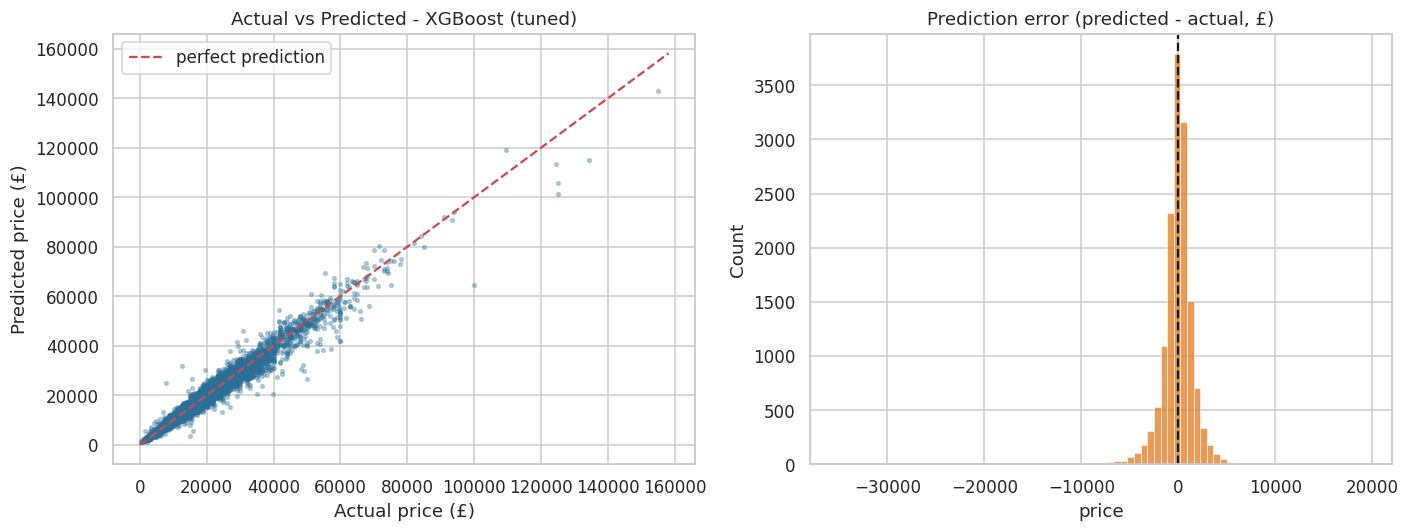

Median absolute error: £717 | 90% of errors are within £2,454


In [28]:
y_pred = final_model.predict(X_test_p)
lim = [0, max(y_test.max(), y_pred.max()) * 1.02]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_test, y_pred, s=6, alpha=0.3, color="#2a6f97")
ax[0].plot(lim, lim, "r--", label="perfect prediction")
ax[0].set_xlabel("Actual price (£)"); ax[0].set_ylabel("Predicted price (£)")
ax[0].set_title(f"Actual vs Predicted - {final_name}"); ax[0].legend()
resid = y_pred - y_test
sns.histplot(resid, bins=80, ax=ax[1], color="#e07a1f")
ax[1].axvline(0, color="k", ls="--"); ax[1].set_title("Prediction error (predicted - actual, £)")
savefig("10_actual_vs_predicted")
print(f"Median absolute error: £{np.median(np.abs(resid)):,.0f} | 90% of errors are within £{np.percentile(np.abs(resid), 90):,.0f}")


**📌 Actual vs predicted.** The points hug the red diagonal: the average error is £1,114 and the typical error is about 5% of the car's price in every price band. The scatter widens for expensive cars, because the same percentage error is a bigger £ amount on a £60k car (see the error analysis below).

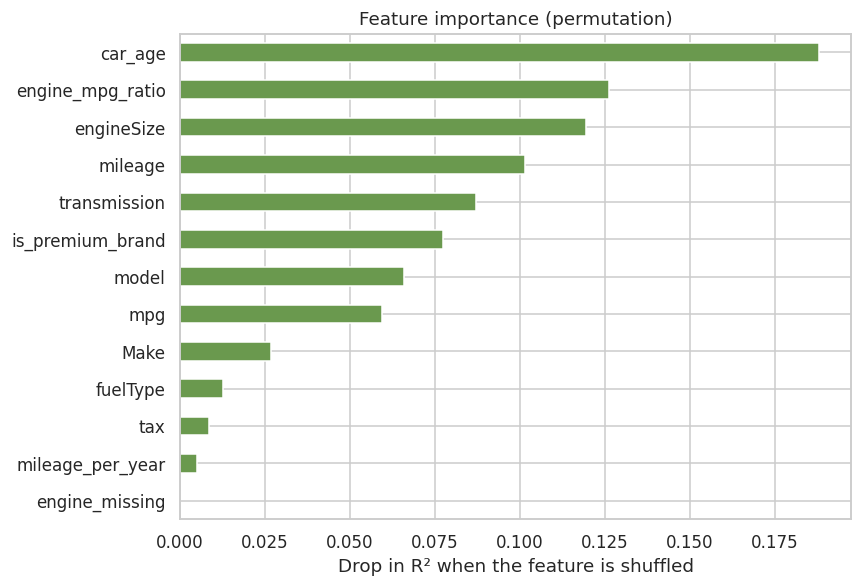

,importance
car_age,0.1881
engine_mpg_ratio,0.1261
engineSize,0.1194
mileage,0.1016
transmission,0.0869
is_premium_brand,0.0773
model,0.0658
mpg,0.0594
Make,0.0267
fuelType,0.0125


In [29]:
# Feature importance: permutation importance on the RAW features (so Make/model/etc. are shown as a whole).
# Shuffle one column at a time on the validation set and measure how much the R² drops.
final_pipe = Pipeline([("prep", preprocessor), ("model", final_model)])
idx = np.random.RandomState(1).choice(len(X_val), 6000, replace=False)
perm = permutation_importance(final_pipe, X_val.iloc[idx], y_val.iloc[idx], scoring="r2",
                              n_repeats=3, random_state=RANDOM_STATE, n_jobs=1)
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
plt.figure(figsize=(8, 5.5))
imp.plot.barh(color="#6a994e")
plt.xlabel("Drop in R² when the feature is shuffled"); plt.title("Feature importance (permutation)")
savefig("11_feature_importance")
display(imp.sort_values(ascending=False).round(4).to_frame("importance"))
RESULTS["feature_importance"] = {k: float(v) for k, v in imp.sort_values(ascending=False).items()}


**📌 Most important features** (drop in R² when the column is shuffled): `car_age` (0.188), `engine_mpg_ratio` (0.126), `engineSize` (0.119), `mileage` (0.102), `transmission` (0.087), `is_premium_brand` (0.077).

* **Vehicle age is the single most important feature** (0.19) — price falls with age.
* **Engine characteristics** (`engine_mpg_ratio`, `engineSize`, `mpg`) together are very important: bigger / more powerful engines cost more.
* **Mileage is also important** (0.10), although less than age: both describe how used the car is, so they share part of the information; `mileage_per_year` adds little (0.005).
* **Transmission** (0.09): automatic / semi-auto cars are priced much higher than manual ones.
* **Manufacturer / brand**: `is_premium_brand`, `model` and `Make` carry the brand effect (Mercedes, Audi, BMW are the most expensive makes). Because they overlap, permutation importance *splits* their credit — the true brand effect is larger than any single bar.
* `engine_missing` is ~0: the imputation of the 265 bad engine sizes did no harm overall (but see the BMW X5 example below).

In [30]:
# Investigate the biggest errors
test_df = X_test.copy()
test_df["Actual"] = y_test
test_df["Predicted"] = y_pred.round(0)
test_df["Error (£)"] = (test_df["Predicted"] - test_df["Actual"]).round(0)
test_df["Error (%)"] = (test_df["Error (£)"] / test_df["Actual"] * 100).round(1)
test_df["abs_err"] = test_df["Error (£)"].abs()
test_df["year"] = REFERENCE_YEAR - test_df["car_age"]

print("Top 10 largest absolute errors:")
cols = ["Make", "model", "year", "mileage", "engineSize", "fuelType", "transmission", "Actual", "Predicted", "Error (£)", "Error (%)"]
display(test_df.sort_values("abs_err", ascending=False)[cols].head(10))

print("Error by manufacturer (MAE in £ and median % error):")
by_make = test_df.groupby("Make").agg(MAE=("abs_err", "mean"), median_pct_err=("Error (%)", lambda s: s.abs().median()),
                                      cars=("abs_err", "size")).round(1).sort_values("MAE")
display(by_make)

test_df["price band"] = pd.cut(test_df["Actual"], [0, 8000, 15000, 25000, 40000, 200000],
                               labels=["<8k", "8-15k", "15-25k", "25-40k", ">40k"])
by_band = test_df.groupby("price band").agg(MAE=("abs_err", "mean"),
                                            median_pct_err=("Error (%)", lambda s: s.abs().median())).round(1)
display(by_band)
RESULTS["error_by_make"] = by_make.to_dict("index")
RESULTS["error_by_band"] = {str(k): v for k, v in by_band.to_dict("index").items()}
RESULTS["worst_errors"] = test_df.sort_values("abs_err", ascending=False)[cols].head(8).astype(str).to_dict("records")


Top 10 largest absolute errors:


,Make,model,year,mileage,engineSize,fuelType,transmission,Actual,Predicted,Error (£),Error (%)
49384,Mercedes,G Class,2015,10000,5.5,Petrol,Semi-Auto,99850,64619.0,-35231.0,-35.3
3342,Audi,R8,2019,100,5.2,Petrol,Automatic,125000,101151.0,-23849.0,-19.1
33011,Ford,Mustang,2017,21575,5.0,Petrol,Manual,49999,26413.0,-23586.0,-47.2
20429,BMW,X5,2016,49000,NaN,Petrol,Automatic,39948,20378.0,-19570.0,-49.0
52292,Mercedes,A Class,2019,1000,4.0,Petrol,Semi-Auto,134219,114905.0,-19314.0,-14.4
700,Audi,Q7,2016,26705,3.0,Diesel,Semi-Auto,12500,31796.0,19296.0,154.4
33008,Ford,Mustang,2017,7546,5.0,Petrol,Automatic,48999,29765.0,-19234.0,-39.3
10365,Audi,R8,2019,13663,5.2,Petrol,Automatic,125000,105881.0,-19119.0,-15.3
96321,Volkswagen,Touareg,2018,10000,3.0,Diesel,Automatic,57295,38505.0,-18790.0,-32.8
96319,Volkswagen,Touareg,2019,9950,3.0,Diesel,Semi-Auto,59990,41756.0,-18234.0,-30.4


Error by manufacturer (MAE in £ and median % error):


,MAE,median_pct_err,cars
Make,,,
Vauxhall,671.0,5.3,1992
Toyota,784.4,4.8,970
Hyundai,800.2,4.9,719
Ford,828.8,5.5,2749
Skoda,913.3,5.4,907
Volkswagen,1088.7,4.9,2212
BMW,1535.9,5.2,1621
Audi,1563.3,5.5,1553
Mercedes,1668.5,5.2,1934


,MAE,median_pct_err
price band,,
<8k,531.9,6.3
8-15k,729.7,5.0
15-25k,1244.1,5.0
25-40k,2040.9,5.2
>40k,4045.3,5.2


**📌 Where does the model make large errors?**
* The **biggest £ errors are rare, expensive cars** (Mercedes G-Class, Audi R8, Ford Mustang, a £134k Mercedes AMG): few similar cars exist, so the model *under-predicts* them (−14% to −47%). On a £100k car even a 15–20% error is £20k.
* In *relative* terms the model is consistent: the median absolute error is about 5% in every price band (5.0–6.3%), but the £ error grows with price (MAE £532 below £8k vs £4,045 above £40k).
* **Cheap brands are predicted most accurately** (Vauxhall £671, Toyota £784, Hyundai £800); premium brands are harder (Mercedes £1,668, Audi £1,563, BMW £1,536) because their prices depend on trim, options and packages that the dataset does not contain.
* **A cleaning side-effect:** a 2016 BMW X5 (£39,948) was predicted at £20,378 (−49%). Its engine size was one of the 265 invalid values that were imputed with the training median (1.6 L), far from the real engine of an X5 — a reminder that imputation has a cost for cars where the missing value matters.
* **A suspicious listing:** a 2016 Audi Q7 diesel with 26k miles is listed at only £12,500 while the model expects £31,796 (+154%). Such a price looks like a damaged car, a typo or a scam, not a model failure — the advisor would call it a "Great Deal", but in real life it should trigger a *"too good to be true — check the car"* warning.
* The model has **no information on condition, trim, options, colour, service history or location**, which limits the achievable accuracy.

In [31]:
# What-if analysis: how does the model price a typical Ford Fiesta 1.0 Petrol Manual as age / mileage change?
def car_row(age, mileage):
    return {"Make": "Ford", "model": "Fiesta", "transmission": "Manual", "fuelType": "Petrol", "tax": 145,
            "mpg": 58.9, "engineSize": 1.0, "car_age": age, "mileage": mileage, "mileage_per_year": mileage / max(age, 1),
            "is_premium_brand": 0, "engine_mpg_ratio": 1.0 / 58.9, "engine_missing": 0}

by_age = pd.DataFrame([car_row(a, 8000 * a) for a in [1, 3, 5, 8, 12]])
by_age["predicted_price"] = final_pipe.predict(by_age[FEATURES]).round(0)
print("Same car, different age (8,000 miles per year):")
display(by_age[["car_age", "mileage", "predicted_price"]])

by_mileage = pd.DataFrame([car_row(5, m) for m in [10000, 30000, 60000, 90000, 120000]])
by_mileage["predicted_price"] = final_pipe.predict(by_mileage[FEATURES]).round(0)
print("Same 5-year-old car, different mileage:")
display(by_mileage[["car_age", "mileage", "predicted_price"]])
RESULTS["what_if_age"] = by_age[["car_age", "predicted_price"]].to_dict("records")
RESULTS["what_if_mileage"] = by_mileage[["mileage", "predicted_price"]].to_dict("records")


Same car, different age (8,000 miles per year):


,car_age,mileage,predicted_price
0,1,8000,14073.0
1,3,24000,10235.0
2,5,40000,7638.0
3,8,64000,5307.0
4,12,96000,2382.0


Same 5-year-old car, different mileage:


,car_age,mileage,predicted_price
0,5,10000,9637.0
1,5,30000,8397.0
2,5,60000,6981.0
3,5,90000,6375.0
4,5,120000,5472.0


**📌 What the model learned about age and mileage** (same Ford Fiesta 1.0 Petrol Manual, only one thing changed):
* **Age:** 1y → £14,073, 3y → £10,235, 5y → £7,638, 8y → £5,307, 12y → £2,382 — steep early depreciation, then flatter.
* **Mileage (5-year-old car):** 10,000 mi → £9,637, 30,000 mi → £8,397, 60,000 mi → £6,981, 90,000 mi → £6,375, 120,000 mi → £5,472 — price falls steadily with mileage.

Both effects have the sign we expect from the EDA: **older and higher-mileage cars are cheaper**, and age has the bigger effect.

## 1️⃣4️⃣ Smart Deal Advisor
`difference = predicted price − seller price` and `% = difference / predicted price`:

| % cheaper than predicted | Rating |
|---|---|
| more than 10% | 🟢 Great Deal |
| 5% to 10% | 🟢 Good Deal |
| within ±5% | 🟡 Fair Price |
| 5% to 10% more expensive | 🟠 Slightly Overpriced |
| more than 10% more expensive | 🔴 Overpriced |

In [32]:
def rate_deal(predicted_price, seller_price):
    """Compare the model's predicted market price with the seller's asking price."""
    difference = predicted_price - seller_price          # > 0  -> seller is cheaper than market
    pct = difference / predicted_price * 100             # % cheaper (+) / more expensive (-)
    if pct > 10:
        label, emoji = "Great Deal", "🟢"
    elif pct > 5:
        label, emoji = "Good Deal", "🟢"
    elif pct >= -5:
        label, emoji = "Fair Price", "🟡"
    elif pct >= -10:
        label, emoji = "Slightly Overpriced", "🟠"
    else:
        label, emoji = "Overpriced", "🔴"
    if difference > 0:
        text = f"£{abs(difference):,.0f} cheaper"
    elif difference < 0:
        text = f"£{abs(difference):,.0f} more expensive"
    else:
        text = "same as market"
    return {"predicted_price": float(predicted_price), "seller_price": float(seller_price),
            "difference": float(difference), "difference_pct": float(pct),
            "difference_text": text, "rating": label, "emoji": emoji}




In [33]:
# Example from the project brief
r = rate_deal(18500, 17000)
print(f"Estimated Market Price: £{r['predicted_price']:,.0f}\nSeller Price: £{r['seller_price']:,.0f}\n"
      f"Difference: {r['difference_text']} ({r['difference_pct']:.1f}%)\nDeal Rating: {r['emoji']} {r['rating']}")

# Boundary tests
for p in [80, 90, 94, 96, 100, 104, 106, 110, 120]:
    print(f"seller asks {p:3d}% of market -> {rate_deal(100, p)['emoji']} {rate_deal(100, p)['rating']}")


Estimated Market Price: £18,500
Seller Price: £17,000
Difference: £1,500 cheaper (8.1%)
Deal Rating: 🟢 Good Deal
seller asks  80% of market -> 🟢 Great Deal
seller asks  90% of market -> 🟢 Good Deal
seller asks  94% of market -> 🟢 Good Deal
seller asks  96% of market -> 🟡 Fair Price
seller asks 100% of market -> 🟡 Fair Price
seller asks 104% of market -> 🟡 Fair Price
seller asks 106% of market -> 🟠 Slightly Overpriced
seller asks 110% of market -> 🟠 Slightly Overpriced
seller asks 120% of market -> 🔴 Overpriced


,% of test listings
rating,
Great Deal,10.0
Good Deal,15.5
Fair Price,48.5
Slightly Overpriced,14.1
Overpriced,11.9


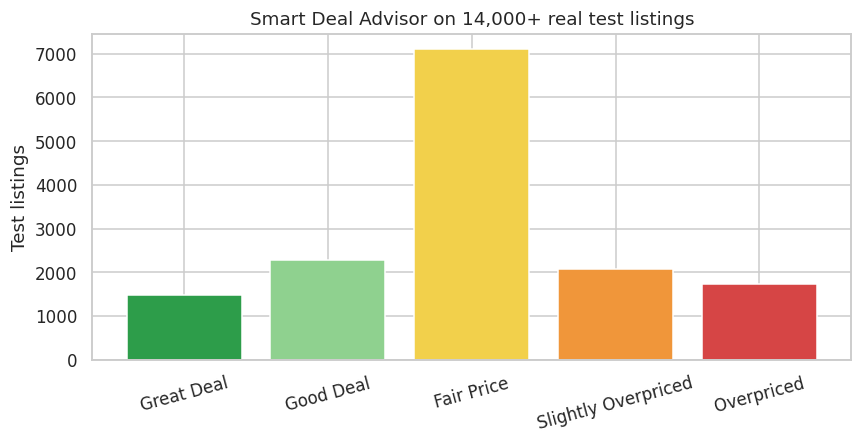

,Make,model,year,mileage,Predicted,Seller price,Difference,Rating
67512,Toyota,Aygo,2018,22864,7095.0,5580.0,"£1,515 cheaper",🟢 Great Deal
51547,Mercedes,SL CLASS,2019,767,53104.0,55710.0,"£2,606 more expensive",🟡 Fair Price
77555,Vauxhall,Mokka X,2017,6049,12137.0,11590.0,£547 cheaper,🟡 Fair Price
32927,Ford,Fiesta,2019,7683,14245.0,17650.0,"£3,405 more expensive",🔴 Overpriced
65012,Toyota,Yaris,2016,27878,11308.0,15230.0,"£3,922 more expensive",🔴 Overpriced


In [34]:
# Apply the advisor to real test-set cars: the seller price is the real advert price
adv = pd.DataFrame([rate_deal(p, s) for p, s in zip(y_pred, y_test)])
dist = adv["rating"].value_counts().reindex(["Great Deal", "Good Deal", "Fair Price", "Slightly Overpriced", "Overpriced"]).fillna(0)
display((dist / len(adv) * 100).round(1).to_frame("% of test listings"))
RESULTS["deal_distribution"] = {k: float(v) for k, v in (dist / len(adv) * 100).items()}

plt.figure(figsize=(8, 4.2))
colors = ["#2d9d4a", "#8fd18f", "#f2d04b", "#f0963a", "#d64545"]
plt.bar(dist.index, dist.values, color=colors)
plt.xticks(rotation=15); plt.ylabel("Test listings"); plt.title("Smart Deal Advisor on 14,000+ real test listings")
savefig("12_deal_distribution")

# A few concrete scenarios on real test cars
demo = test_df.sample(5, random_state=7)[["Make", "model", "year", "mileage", "Actual", "Predicted"]].copy()
demo["Seller price"] = (demo["Actual"] * [0.82, 0.93, 1.00, 1.07, 1.20]).round(-1)
demo["Difference"] = demo.apply(lambda r: rate_deal(r["Predicted"], r["Seller price"])["difference_text"], axis=1)
demo["Rating"] = demo.apply(lambda r: "{} {}".format(*[rate_deal(r["Predicted"], r["Seller price"])[k] for k in ("emoji", "rating")]), axis=1)
display(demo.drop(columns="Actual"))


**📌 Discussion.** Applying the advisor to the ~14,700 real test listings (seller price = real advert price): **48% are rated Fair Price**, 26% are good/great deals and 26% are overpriced — an almost symmetric picture, as expected from a well-calibrated model: asking prices scatter around the market price. The advisor is only as good as the price estimate: with a typical error of about 5%, ratings close to the ±5% boundaries should be read as *"roughly fair"*.

## 1️⃣5️⃣ Final application (Streamlit)
Everything the app needs is saved in `models/autoworth_model.joblib`: the fitted preprocessor, the final model, the dropdown options (models per make, fuel types, transmissions and engine sizes seen for each model) and typical `tax` / `mpg` values per make + model + fuel + engine + transmission (computed on the **training** data) — so the user only has to enter the 8 fields from the brief and the app fills in tax/mpg automatically (they can still be overridden).

Run locally: `pip install -r requirements.txt` then `streamlit run app.py`.

In [35]:
# Save everything the Streamlit app needs: fitted preprocessor + final model + dropdown options + typical tax/mpg
train_df = df.loc[X_train.index]
def med_table(cols):
    g = train_df.groupby(cols)[["tax", "mpg"]].median()
    return {"|".join(f"{v:.1f}" if isinstance(v, float) else str(v) for v in (k if isinstance(k, tuple) else (k,))):
            {"tax": float(r["tax"]), "mpg": float(r["mpg"])} for k, r in g.iterrows()}

defaults = {
    "make_model_fuel_engine_trans": med_table(["Make", "model", "fuelType", "engineSize", "transmission"]),
    "make_model_fuel_engine": med_table(["Make", "model", "fuelType", "engineSize"]),
    "make_model_fuel": {f"{k[0]}|{k[1]}|{k[2]}": {"tax": float(v["tax"]), "mpg": float(v["mpg"])}
                        for k, v in train_df.groupby(["Make", "model", "fuelType"])[["tax", "mpg"]].median().iterrows()},
    "make_model": {f"{k[0]}|{k[1]}": {"tax": float(v["tax"]), "mpg": float(v["mpg"])}
                   for k, v in train_df.groupby(["Make", "model"])[["tax", "mpg"]].median().iterrows()},
    "global": {"tax": float(train_df.tax.median()), "mpg": float(train_df.mpg.median())},
}
options = {
    "models_by_make": {m: sorted(g.model.unique().tolist()) for m, g in df.groupby("Make")},
    "fuels_by_model": {f"{k[0]}|{k[1]}": sorted(g.fuelType.unique().tolist()) for k, g in df.groupby(["Make", "model"])},
    "transmissions_by_model": {f"{k[0]}|{k[1]}": sorted(g.transmission.unique().tolist()) for k, g in df.groupby(["Make", "model"])},
    "engines_by_model": {f"{k[0]}|{k[1]}": sorted({float(e) for e in g.engineSize.dropna().unique() if e > 0})
                         for k, g in df.groupby(["Make", "model"])},
    "year_range": [int(df.year.min()), int(df.year.max())],
    "max_mileage": int(df.mileage.max()),
}
bundle = {"preprocessor": preprocessor, "model": final_model, "features": FEATURES, "model_name": final_name,
          "defaults": defaults, "options": options, "test_metrics": RESULTS["test"]}
joblib.dump(bundle, "models/autoworth_model.joblib", compress=3)
print("Saved models/autoworth_model.joblib", round(os.path.getsize("models/autoworth_model.joblib") / 1e6, 1), "MB")


Saved models/autoworth_model.joblib 4.7 MB


In [36]:
def predict_price(bundle, make, model, year, mileage, transmission, fuel_type, engine_size,
                  tax=None, mpg=None):
    """Predict the market price for ONE car. Missing tax / mpg are filled with typical
    values for the same make+model+fuel (computed from the TRAINING data only)."""
    d = bundle["defaults"]
    eng = f"{float(engine_size):.1f}"
    ref = (d["make_model_fuel_engine_trans"].get(f"{make}|{model}|{fuel_type}|{eng}|{transmission}")
           or d["make_model_fuel_engine"].get(f"{make}|{model}|{fuel_type}|{eng}")
           or d["make_model_fuel"].get(f"{make}|{model}|{fuel_type}")
           or d["make_model"].get(f"{make}|{model}")
           or d["global"])
    tax = ref["tax"] if tax is None else tax
    mpg = ref["mpg"] if mpg is None else mpg
    row = pd.DataFrame([{"Make": make, "model": model, "year": year, "mileage": mileage,
                         "transmission": transmission, "fuelType": fuel_type,
                         "tax": tax, "mpg": mpg, "engineSize": engine_size}])
    row = add_features(row)
    X = bundle["preprocessor"].transform(row[bundle["features"]])
    return float(bundle["model"].predict(X)[0])


In [37]:
# End-to-end test exactly like the app: only the 8 user inputs (tax/mpg are filled automatically)
res = predict_price(bundle, "Audi", "A3", 2017, 35000, "Manual", "Petrol", 1.4)
print(f"Predicted market price for a 2017 Audi A3 1.4 Petrol Manual, 35k miles: £{res:,.0f}")
r = rate_deal(res, 14500)
print(f"Seller asks £14,500 -> {r['difference_text']} ({r['difference_pct']:.1f}%) -> {r['emoji']} {r['rating']}")

with open("results.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)
print("results.json saved")


Predicted market price for a 2017 Audi A3 1.4 Petrol Manual, 35k miles: £15,445
Seller asks £14,500 -> £945 cheaper (6.1%) -> 🟢 Good Deal
results.json saved


## ✅ Final conclusions
* **Result:** the final model (XGBoost (tuned)) reaches **R² = 0.967** and **MAE ≈ £1,114** on unseen cars — above the R² > 0.90 target — with a typical error of about 5% of the car's price.
* **What drives price:** vehicle age first, then engine characteristics, brand/model and transmission; mileage matters but overlaps strongly with age.
* **Methodology:** duplicates and impossible values were investigated before being removed; imputation, scaling and encoding were fitted on the training set only; the test set was used exactly once; tuning used cross-validation inside a pipeline.
* **Model comparison:** tree-based ensembles beat linear regression on error (MAE ≈ £1.1k vs £1.6k) although the log-target linear model was surprisingly competitive on R².
* **Smart Deal Advisor:** turns a price estimate into a clear decision (🟢🟡🟠🔴) and is available as a Streamlit app.

**Limitations:** the data is from 2020 (prices today differ), UK only, nine makes; no trim level, condition, options, service history or location; `tax`/`mpg` are auto-filled in the app when the user does not know them; extreme-value cars (supercars, G-Class) have larger errors.

**Future work:** add trim/condition features, retrain on fresh listings, predict a price *interval* (not just a point estimate), try CatBoost / stacking.

## 📦 Download the outputs (Colab only)
Packages the figures, the trained model and `results.json` into one zip and downloads it, so they can be uploaded to the GitHub repository.

In [38]:
try:
    from google.colab import files
    !zip -qr outputs.zip figures models results.json
    files.download("outputs.zip")
except ImportError:
    print("Not running on Colab - the files are already in the figures/ and models/ folders.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>